# 3D Leslie — spurious vs. correct latent dynamics (paper §5.3)

The same 3-generation Leslie map, compressed to a **2D latent space**, under two training regimes:

- **Spurious (§5.3.1):** the latent Morse graph reports an *extra* attractor whose lift fails the semiconjugacy check — a failure the example is built to expose.
- **Correct (§5.3.2):** the latent Morse graph recovers the true bistable structure.

Both regimes are replayed from saved artifacts (no training, no CMGDB recompute).

## Spurious regime (§5.3.1)

In [1]:
from latentdynamics.replay import load_experiment

exp_sp = load_experiment("leslie3d_spurious")
exp_sp

ReplayExperiment(name='leslie3d_spurious', seed=None, train_file='train', dims=3->2, device='mps')

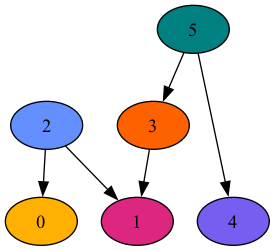

In [2]:
exp_sp.show_morse_graph()

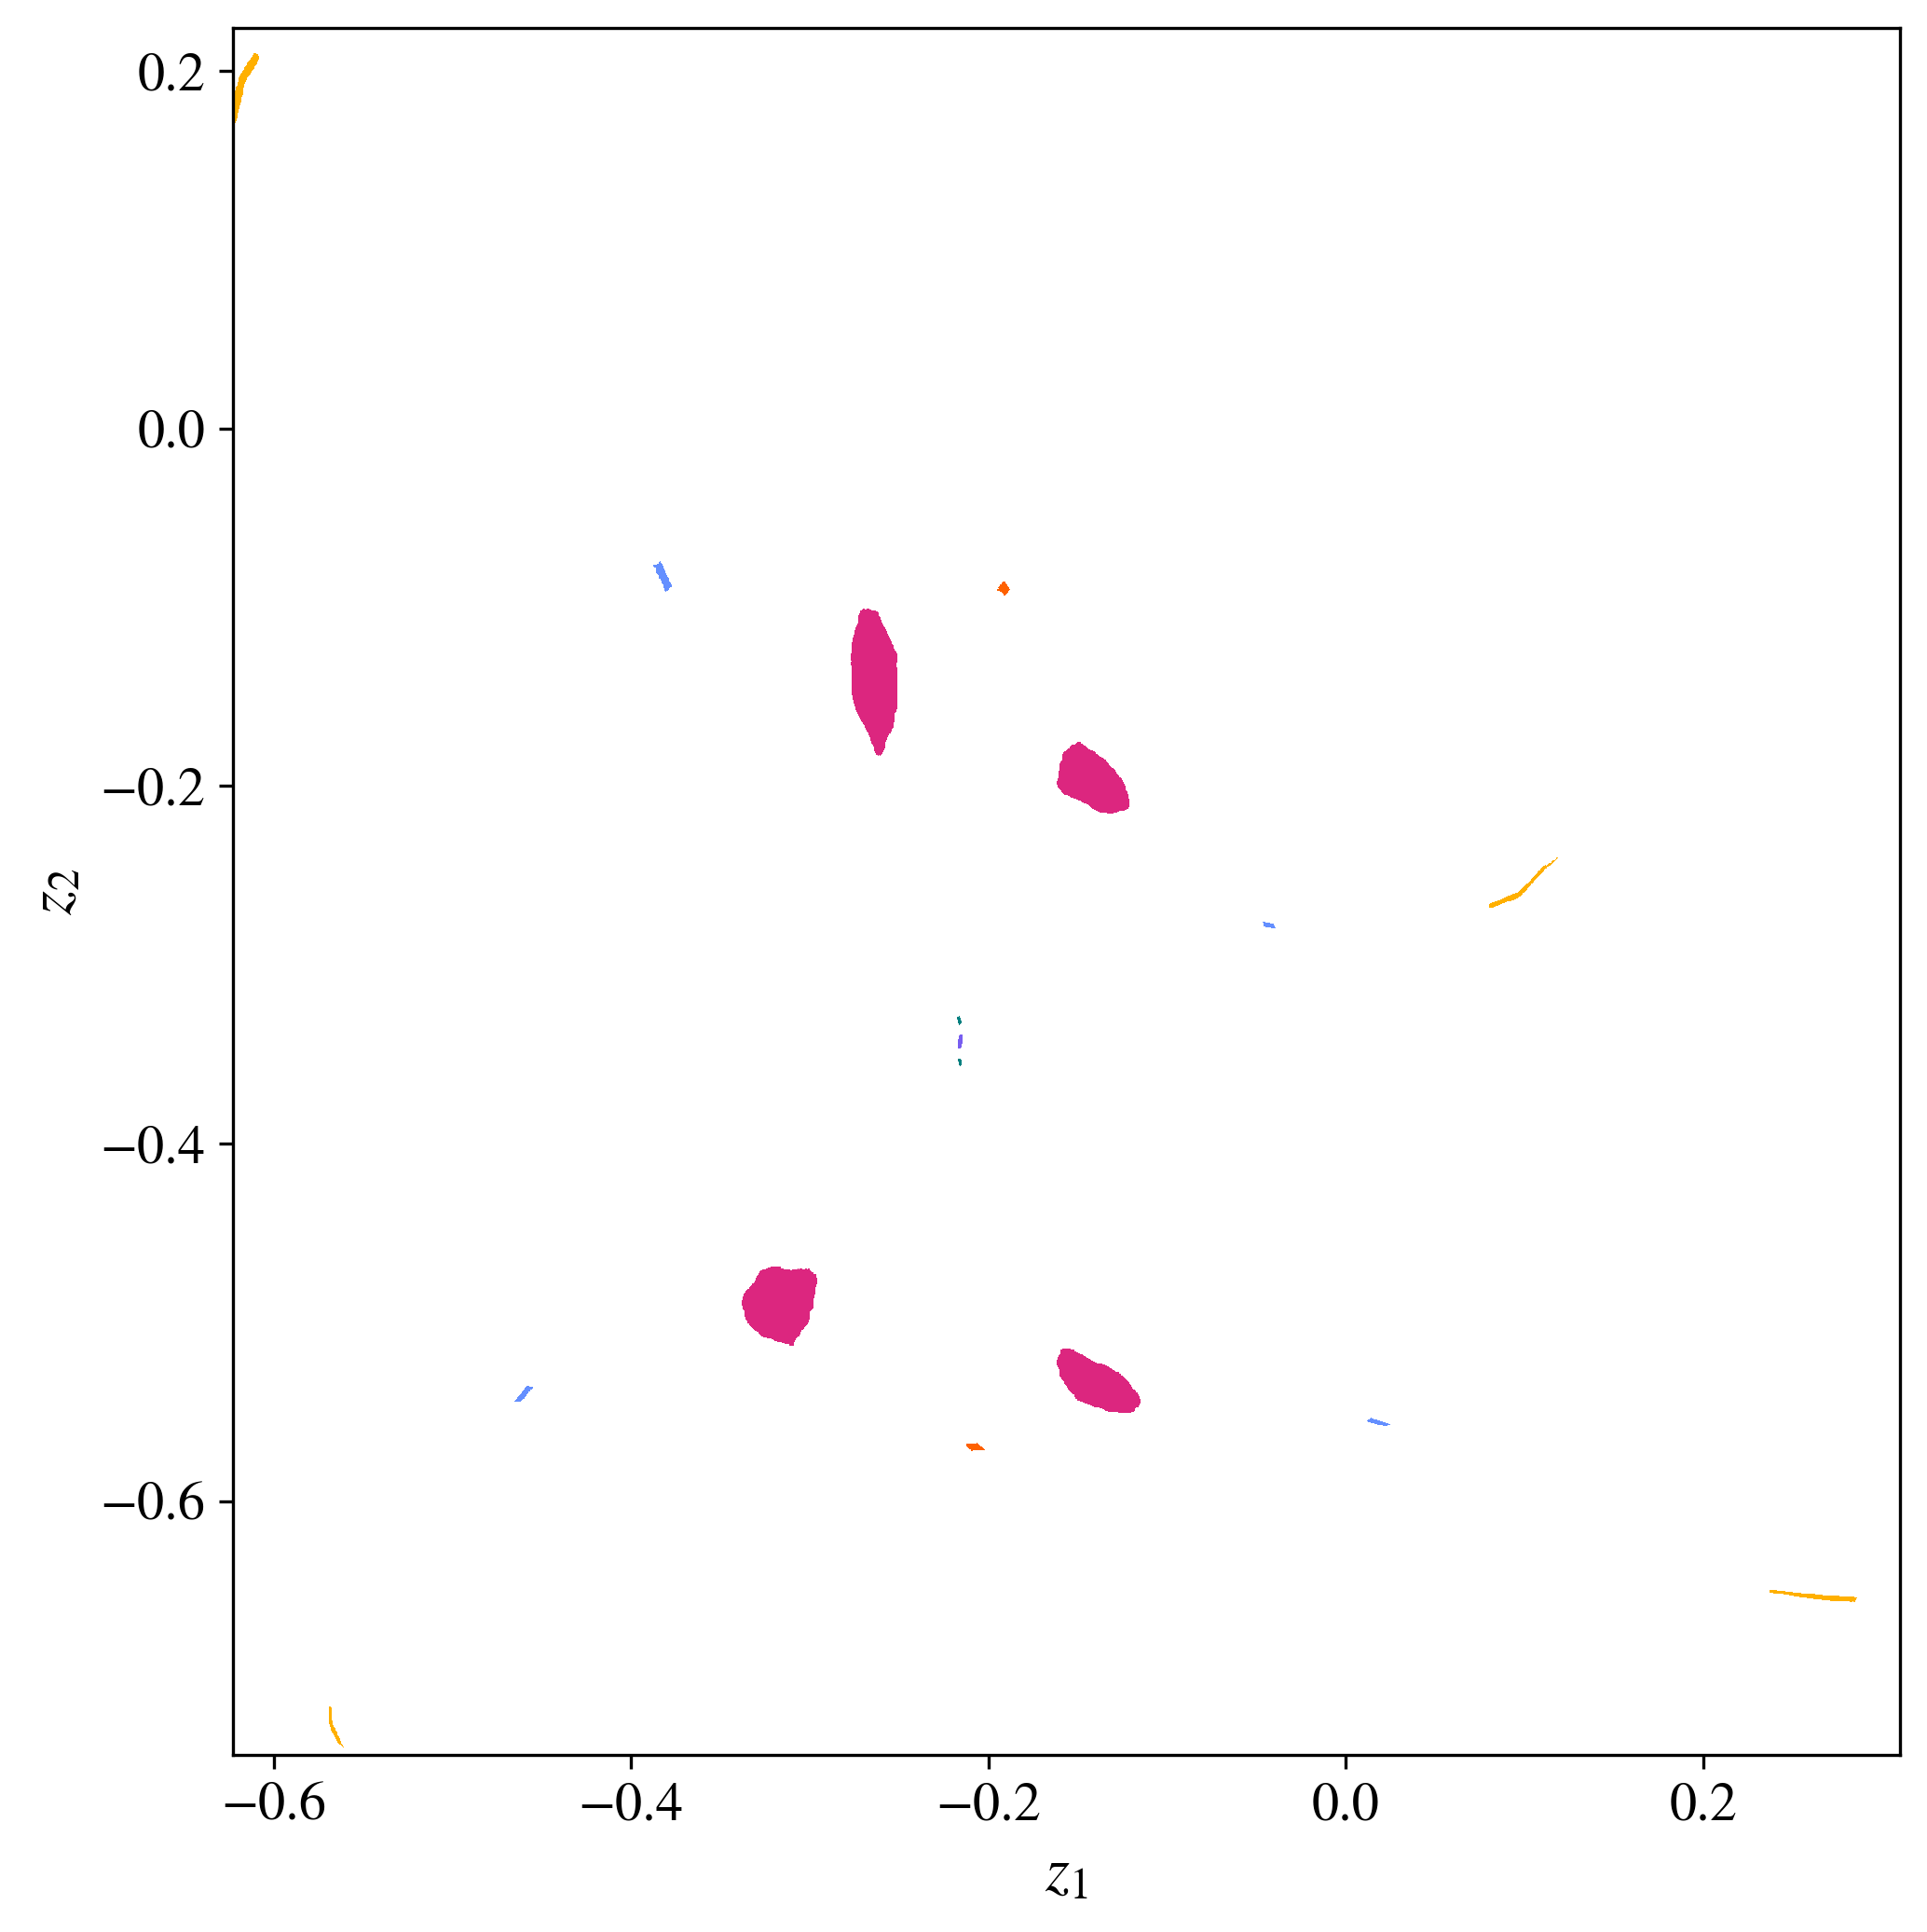

In [3]:
exp_sp.show_morse_sets()

### Latent trajectories of the two 4-periodic orbits

Each orbit is encoded into the latent space and pushed forward four times under the latent map. The orbit inside the spurious Morse set never settles to a fixed point — that is the failure this example exposes.

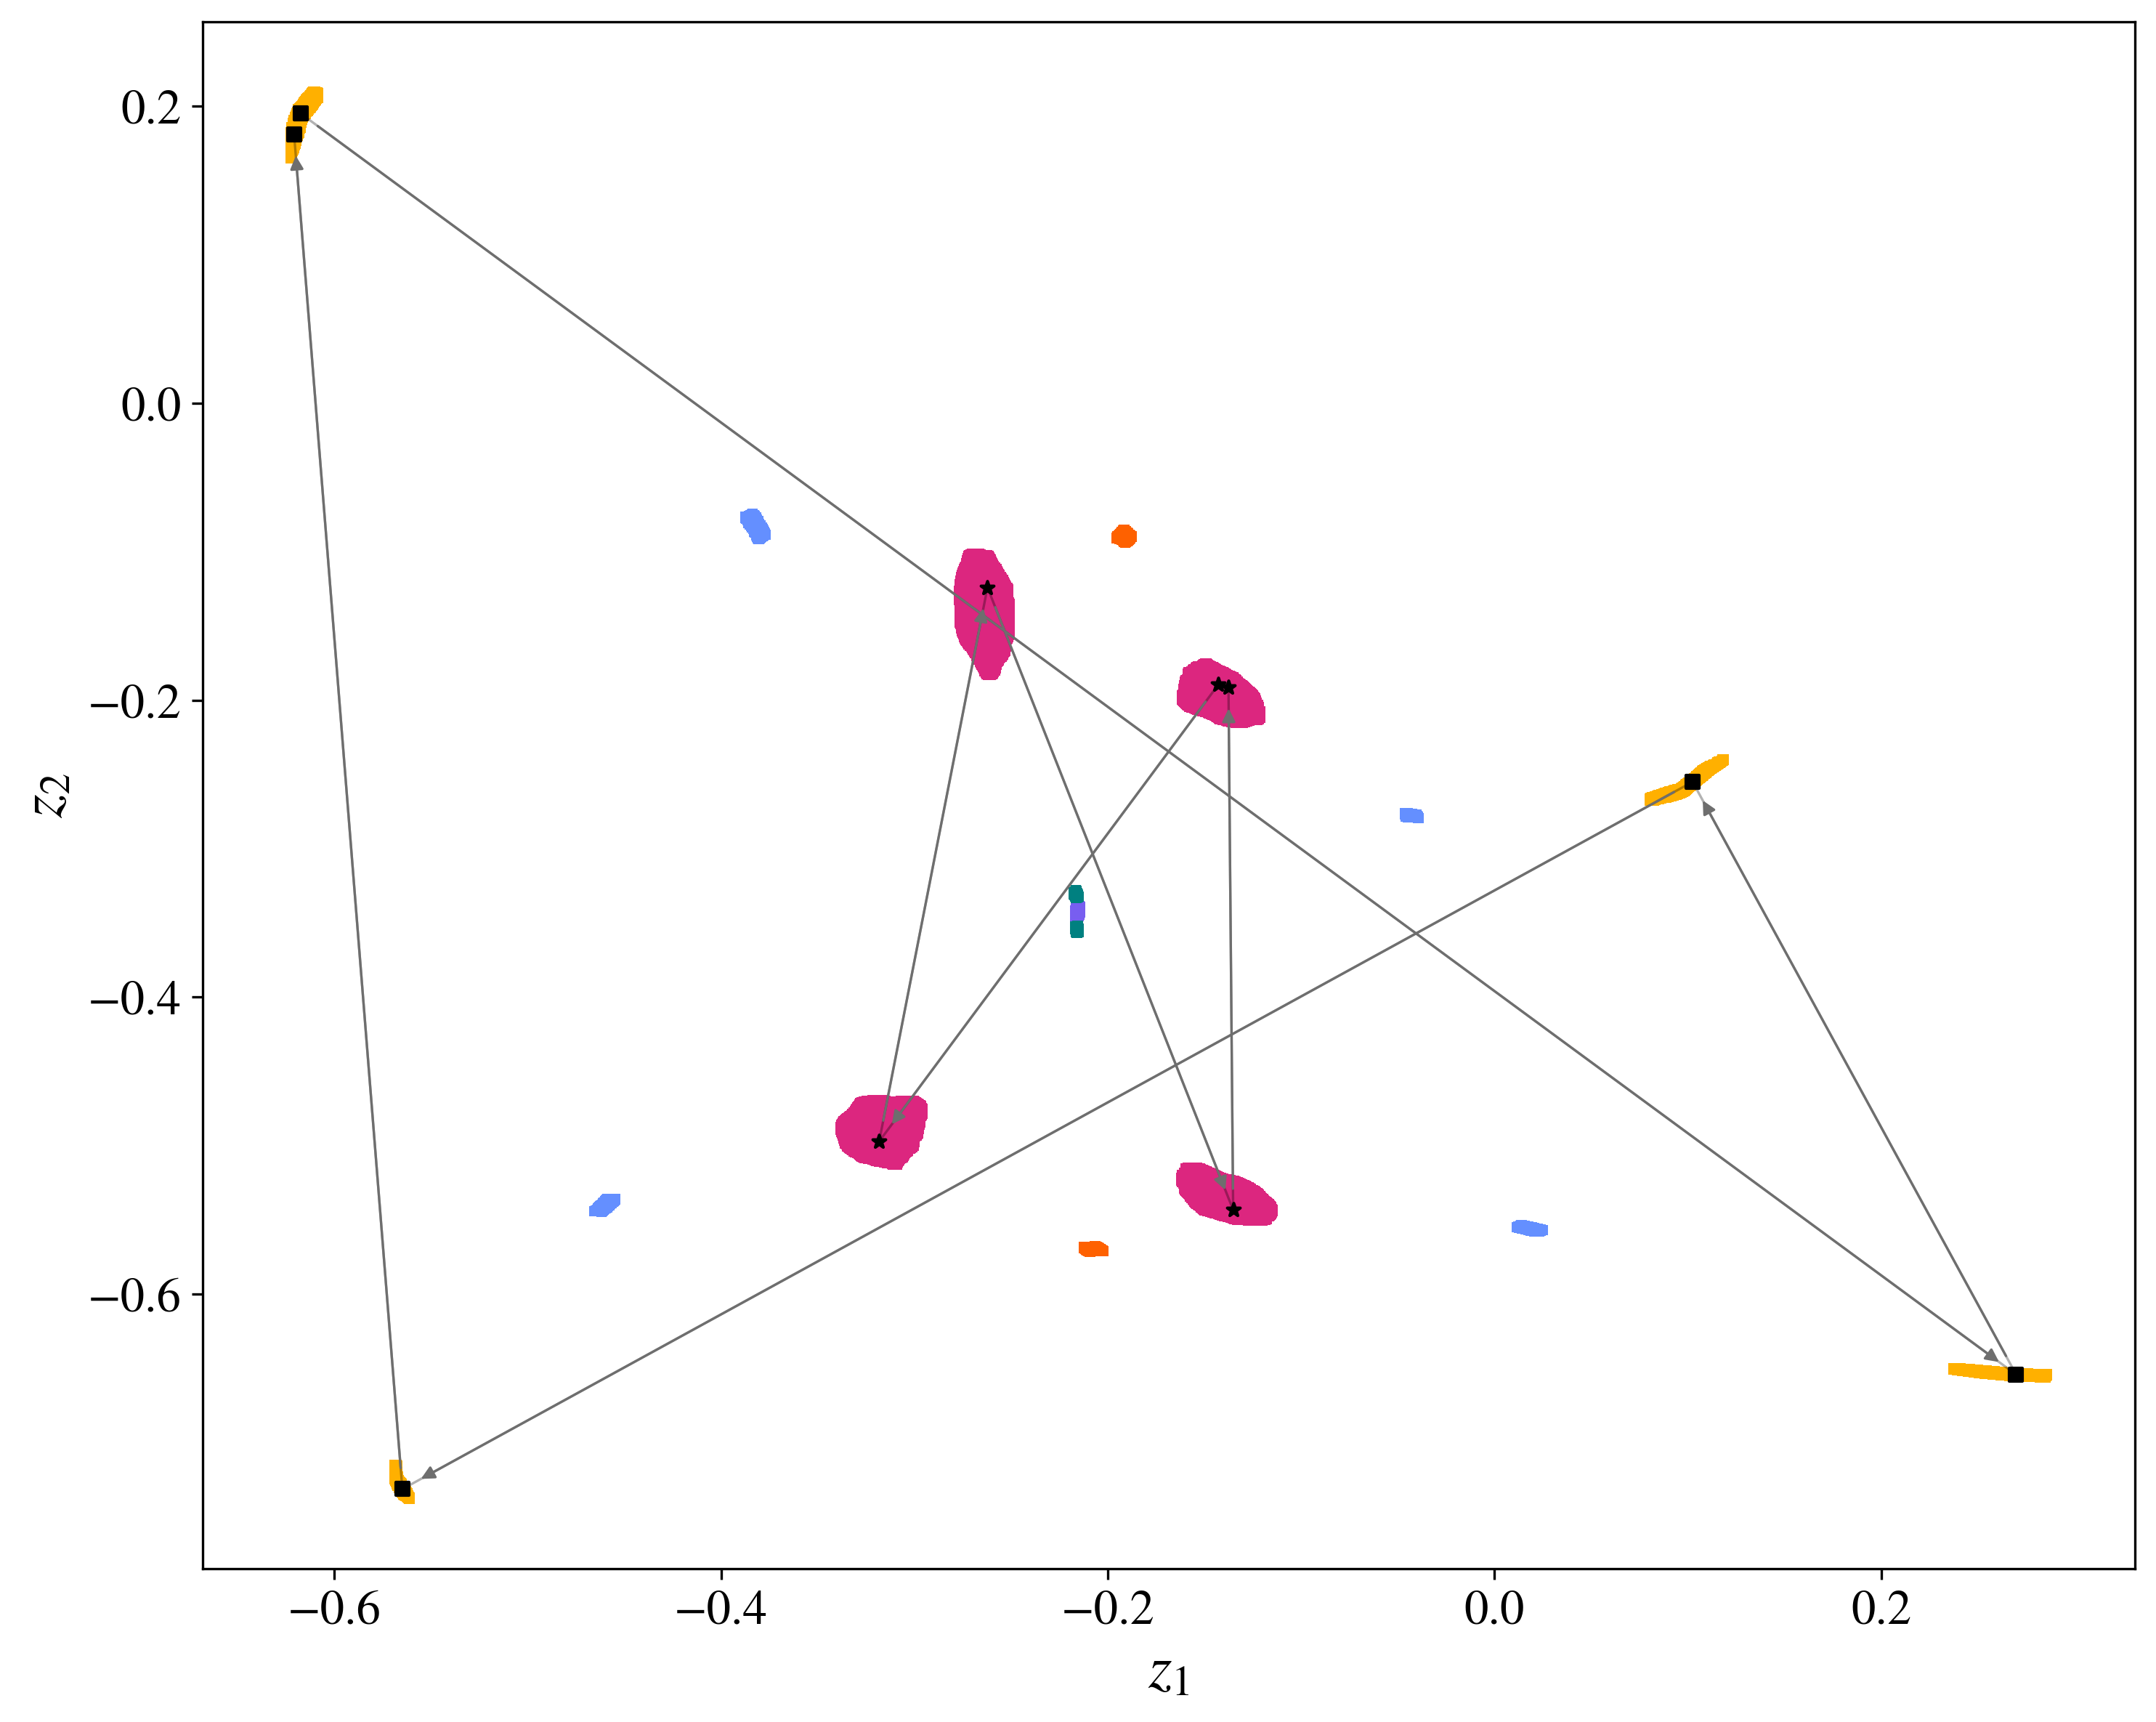

In [4]:
from latentdynamics.cli.render import LESLIE3D_PERIODIC_PTS

exp_sp.show_latent_trajectory(LESLIE3D_PERIODIC_PTS, steps=4)

## Correct regime (§5.3.2)

Retrained so the latent Morse graph is bistable and matches the ambient structure.

In [5]:
exp_ok = load_experiment("leslie3d_success")
exp_ok

ReplayExperiment(name='leslie3d_success', seed=None, train_file='train', dims=3->2, device='mps')

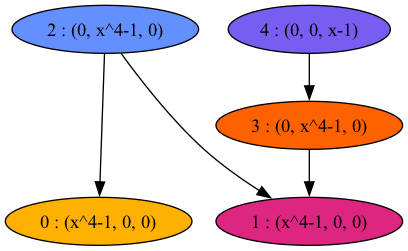

In [6]:
exp_ok.show_morse_graph()

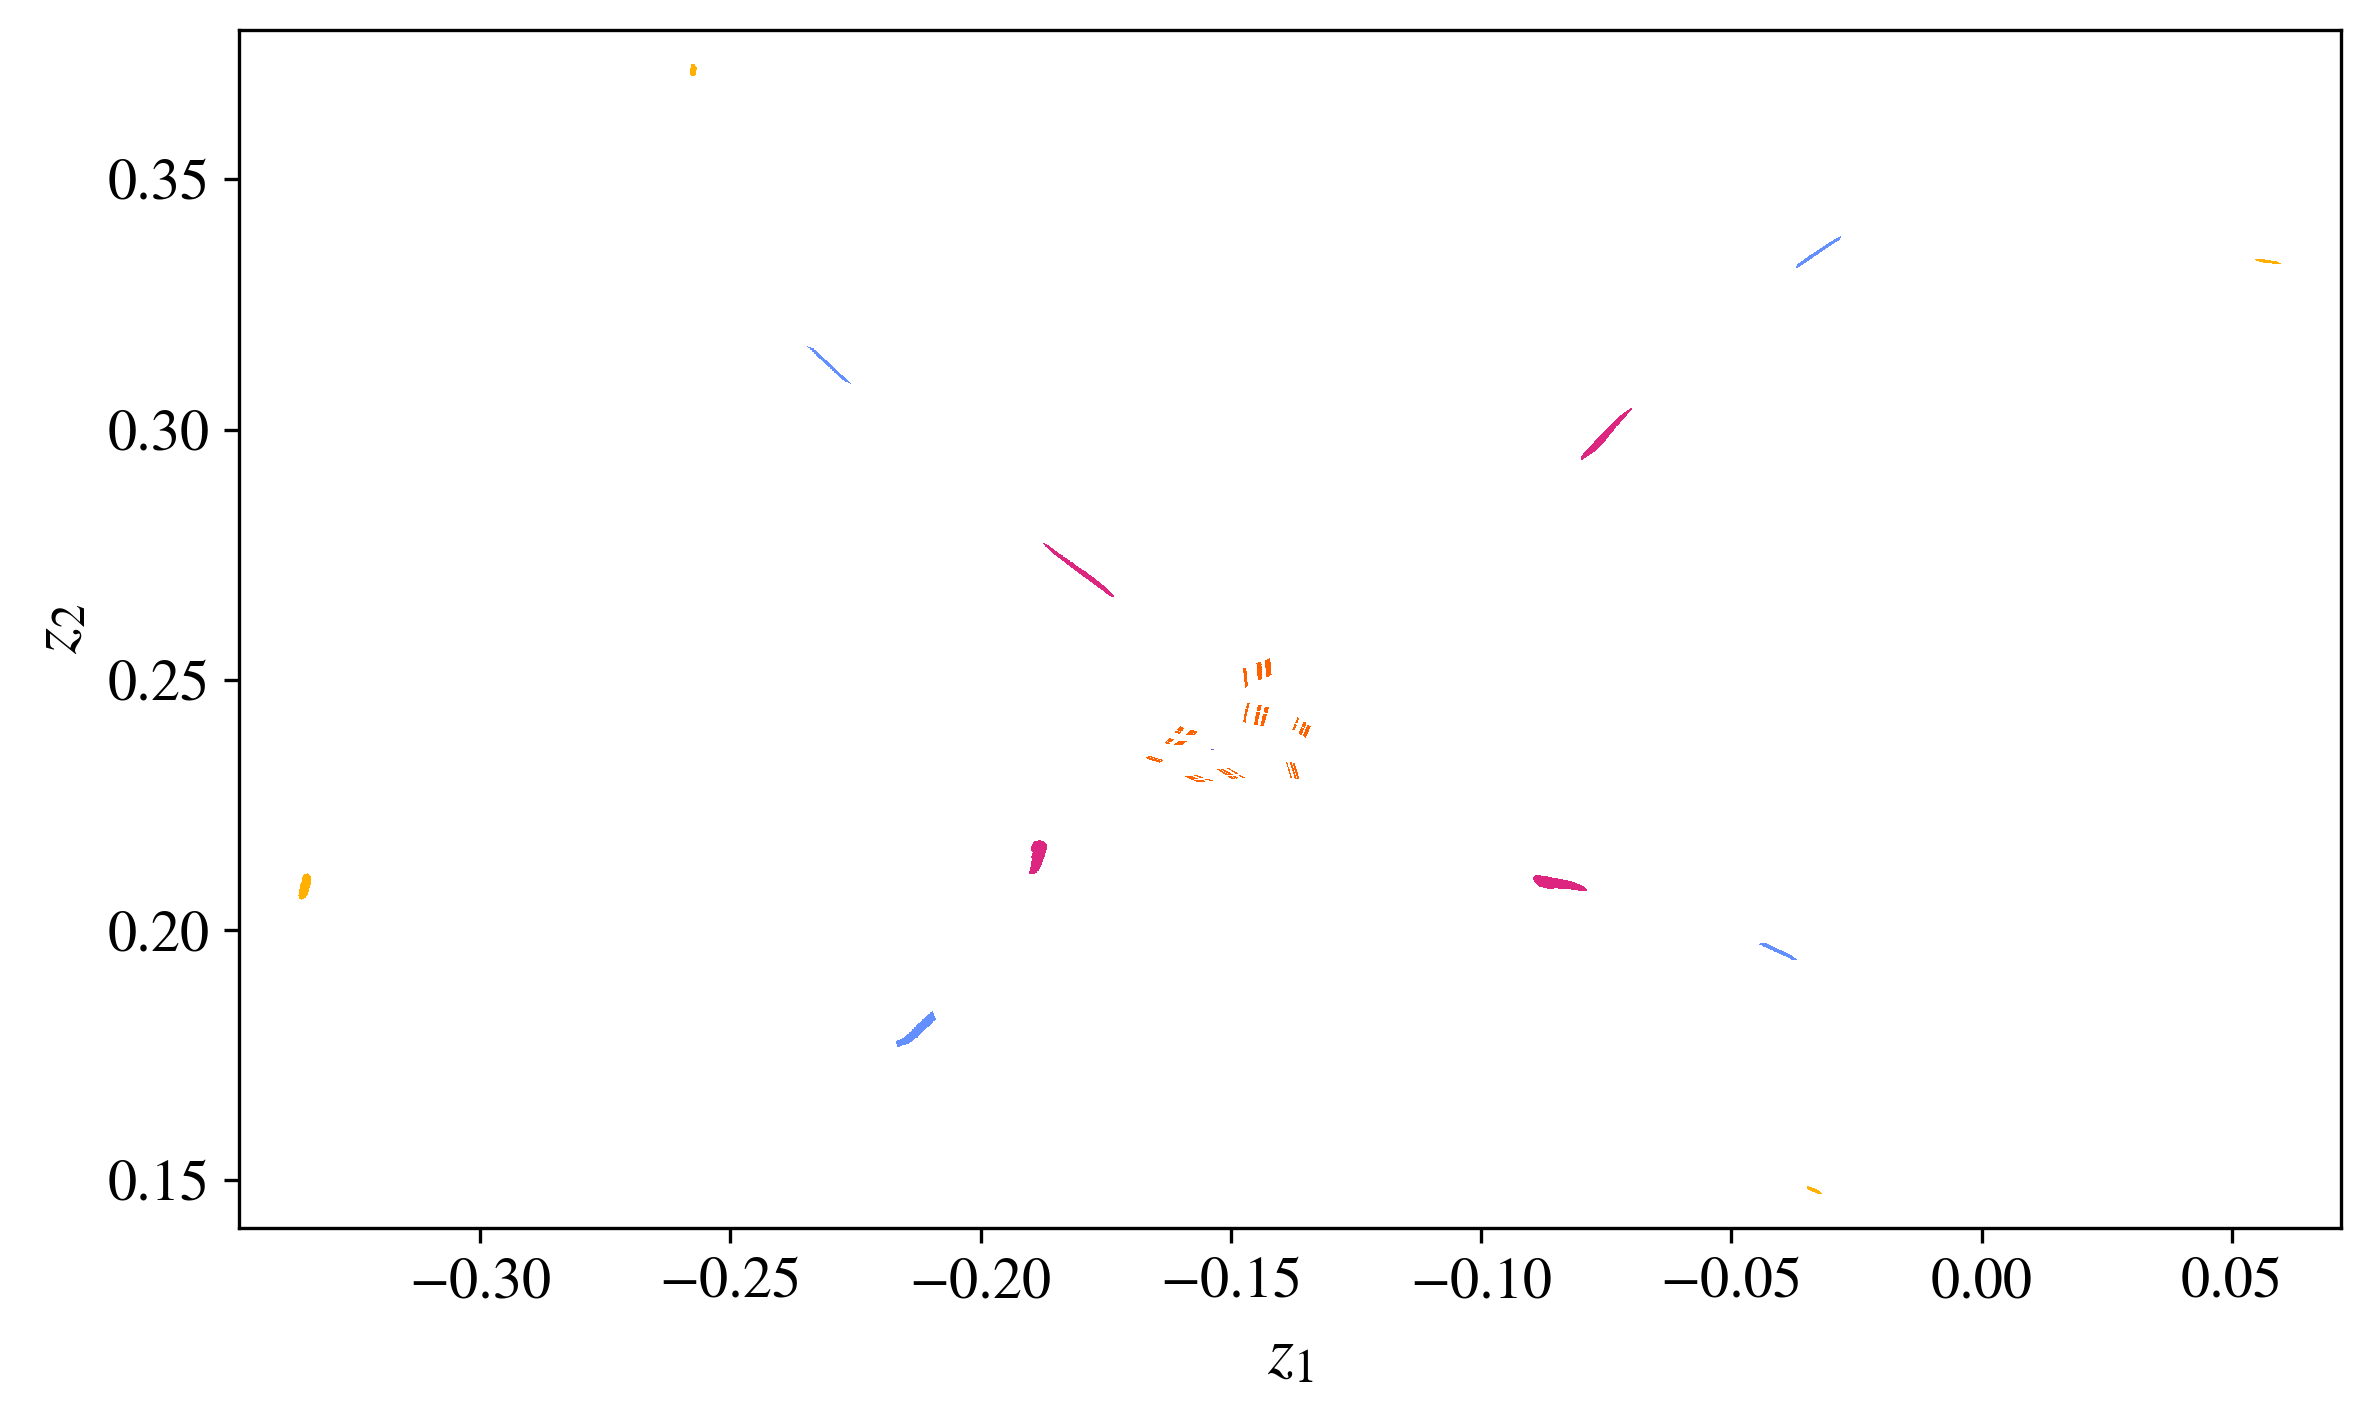

In [7]:
exp_ok.show_morse_sets()

## Run provenance

In [8]:
exp_sp.diagnostics()

{'experiment': 'leslie3d_spurious',
 'seed': None,
 'train_file': 'train',
 'dims': '3 -> 2',
 'seed_dir': 'replay_sources/leslie3d_spurious/spurious_attractor_ex',
 'final_losses': '--- Final losses ---\nL1: 5.268487836929126e-06\nL2: 0.00011298822732896951\nL3: 6.159611615430549e-05',
 'mg_params': {'lower_bounds': '[-0.6228695, -0.74216413]',
  'upper_bounds': '[0.30980384, 0.22416562]',
  'subdivision_init': '23',
  'subdivision_min': '23',
  'subdivision_max': '27',
  'subdivision_limit': '10000',
  'program_duration': '94 minutes'},
 'metrics': {'target_label': 0,
  'tau_bar': 5.960464477539063e-08,
  'max_semiconjugacy_error': 0.0004470703424885869,
  'is_spurious_attractor': True}}

In [9]:
exp_ok.diagnostics()

{'experiment': 'leslie3d_success',
 'seed': None,
 'train_file': 'train',
 'dims': '3 -> 2',
 'seed_dir': 'replay_sources/leslie3d_success',
 'final_losses': '--- Final losses ---\nL1: 1.429655264291796e-05\nL2: 0.00011943868521484547\nL3: 1.7363839215249755e-05',
 'mg_params': {'lower_bounds': '[-0.37490714, -0.4695556]',
  'upper_bounds': '[0.3535685, 0.455769]',
  'subdivision_init': '25',
  'subdivision_min': '28',
  'subdivision_max': '29',
  'subdivision_limit': '10000',
  'program_duration': '691 minutes'}}